In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

In [19]:
Dt_T20 = pd.DataFrame({
    'd': [2.1, 2.1, 0.7, 0.55],
    't1': [32.55, 31.95, 37.98, 58.12],
    't2': [32.37, 32.07, 37.83, 58.55]
})

Dt_T30  = pd.DataFrame({
    'd': [2.05, 2.02, 0.8, 0.85],
    't1': [14.22, 14.11, 17.08, 14.37],
    't2': [14.21, 14.17, 17.23, 14.33]
})

Dt_T40 = pd.DataFrame({
    'd': [2.05, 2.1, 0.8, 0.8],
    't1': [7.22, 7.05, 8.01, 7.13],
    't2': [7.28, 7.05, 7.86, 7.19]
})

Dt_T50 = pd.DataFrame({
    'd': [2.08, 2.06, 0.94, 0.96],
    't1': [3.8, 3.82, 4.05, 3.54],
    't2': [3.81, 3.78, 3.96, 3.53]
})

Dt_T60 = pd.DataFrame({
    'd': [2.06, 2.1, 0.98, 0.9],
    't1': [2.45, 2.35, 2.42, 2.3],
    't2': [2.45, 2.4, 2.45, 2.35]
})

l1 = 0.1
l2 = 0.099
p1 = 2500
p2 = 7800
pg = [1260, 1255.5, 1251.1, 1246.6, 1242.2]
data_list = [Dt_T20, Dt_T30, Dt_T40, Dt_T50, Dt_T60]

In [61]:
vyazkost = {
    'T20' : [],
    'T30' : [],
    'T40' : [],
    'T50' : [],
    'T60' : [],
}
def rasch_vya(temp):
    data=data_list[temp//10-2]
    for i in range(4):
        V_ust = (l1/data['t1'][i]+l2/data['t2'][i])/2
        if i < 2:
            vyazkost['T'+str(temp)].append(float(9.8*(p1-pg[temp//10-2])/18*pow(data['d'][i]/1000, 2)/V_ust))
        elif temp != 20:
             vyazkost['T'+str(temp)].append(float(9.8*(p2-pg[temp//10-2])/18*pow(data['d'][i]/1000, 2)/V_ust))
rasch_vya(20)
rasch_vya(30)
rasch_vya(40)
rasch_vya(50)
rasch_vya(60)

print(vyazkost)

def sredn():
    for temp in range(20, 70, 10):
        vyazkost['T'+str(temp)]=sum(vyazkost['T'+str(temp)])/len(vyazkost['T'+str(temp)])

sredn()

print(vyazkost)

def inlinst():
    LIST = []
    for temp in range(20, 70, 10):
        LIST.append(vyazkost['T'+str(temp)])
    return LIST

vyazkost=inlinst()

print(vyazkost)
T_list = [1/293, 1/303, 1/313, 1/323, 1/333]
lnv = np.log(vyazkost)

{'T20': [0.9712745122076957, 0.9577911549391293], 'T30': [0.4067997626223848, 0.39288998091440946, 0.3931513906722282, 0.3712777405187384], 'T40': [0.2082032082710138, 0.2124642486934674, 0.18197326264024472, 0.16420072740372882], 'T50': [0.1129010272747174, 0.1105955552764009, 0.12688932421565216, 0.11682378389918628], 'T60': [0.07155543155823564, 0.07207309760710887, 0.08390925203009801, 0.06756518205748865]}
{'T20': 0.9645328335734125, 'T30': 0.39102971868194025, 'T40': 0.19171036175211367, 'T50': 0.11680242266648919, 'T60': 0.07377574081323279}
[0.9645328335734125, 0.39102971868194025, 0.19171036175211367, 0.11680242266648919, 0.07377574081323279]


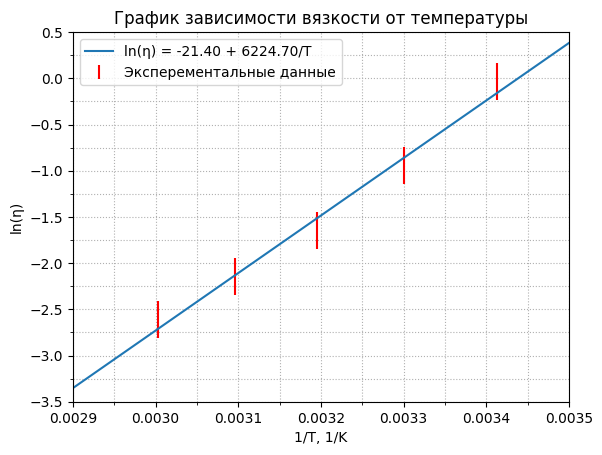

In [71]:
plt.errorbar(T_list, lnv, label='Эксперементальные данные',yerr=[0.20, 0.20, 0.20, 0.20, 0.20], ecolor='red', color='none')
coeffs = np.polyfit(T_list, lnv, deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(0.0029, 0.0035, 100)
y = poly_func(x)
plt.plot(x, y, label=f"ln(η) = {coeffs[1]:.2f} + {coeffs[0]:.2f}/T")
ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.00005))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(0.0029, 0.0035)
ax.set_ylim(-3.5, 0.5)
plt.title('График зависимости вязкости от температуры')
plt.xlabel("1/T, 1/K")
plt.ylabel("ln(η)")
plt.show()